# Tutorial 4a: Clasificación con SVM, Random Forest, Gradient Boosting y XGBoost

## Introducción 

En este tutorial vamos a practicar la implementación de varios modelos de clasificación usando el famoso dataset **Iris**. El objetivo es aprender a entrenar, evaluar y comparar los siguientes algoritmos:

1. **Support Vector Machines (SVM)**
2. **Random Forest**
3. **Gradient Boosting**
4. **XGBoost**
5. Finalmente, usaremos **PyCaret** para automatizar el proceso de entrenamiento y comparación de modelos.

El dataset Iris contiene 150 muestras de tres especies de flores (*setosa*, *versicolor*, *virginica*), cada una descrita por 4 características: largo y ancho del sépalo, y largo y ancho del pétalo.

## 1. Importación de librerías

Como siempre, comenzamos importando las librerías más comunes que vamos a usar a lo largo del notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import seaborn as sns
from xgboost import XGBClassifier
%matplotlib inline

np.random.seed(43)

## 2. Carga del dataset Iris

El dataset Iris está disponible directamente en `scikit-learn`, así que lo cargamos desde allí.

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='species')
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
print("Clases:", iris.target_names)
print("Distribución de clases:")
print(y.value_counts())

Clases: ['setosa' 'versicolor' 'virginica']
Distribución de clases:
species
0    50
1    50
2    50
Name: count, dtype: int64


### Visualización rápida
Vamos a graficar las características usando un *pairplot* para entender cómo se distribuyen las clases.

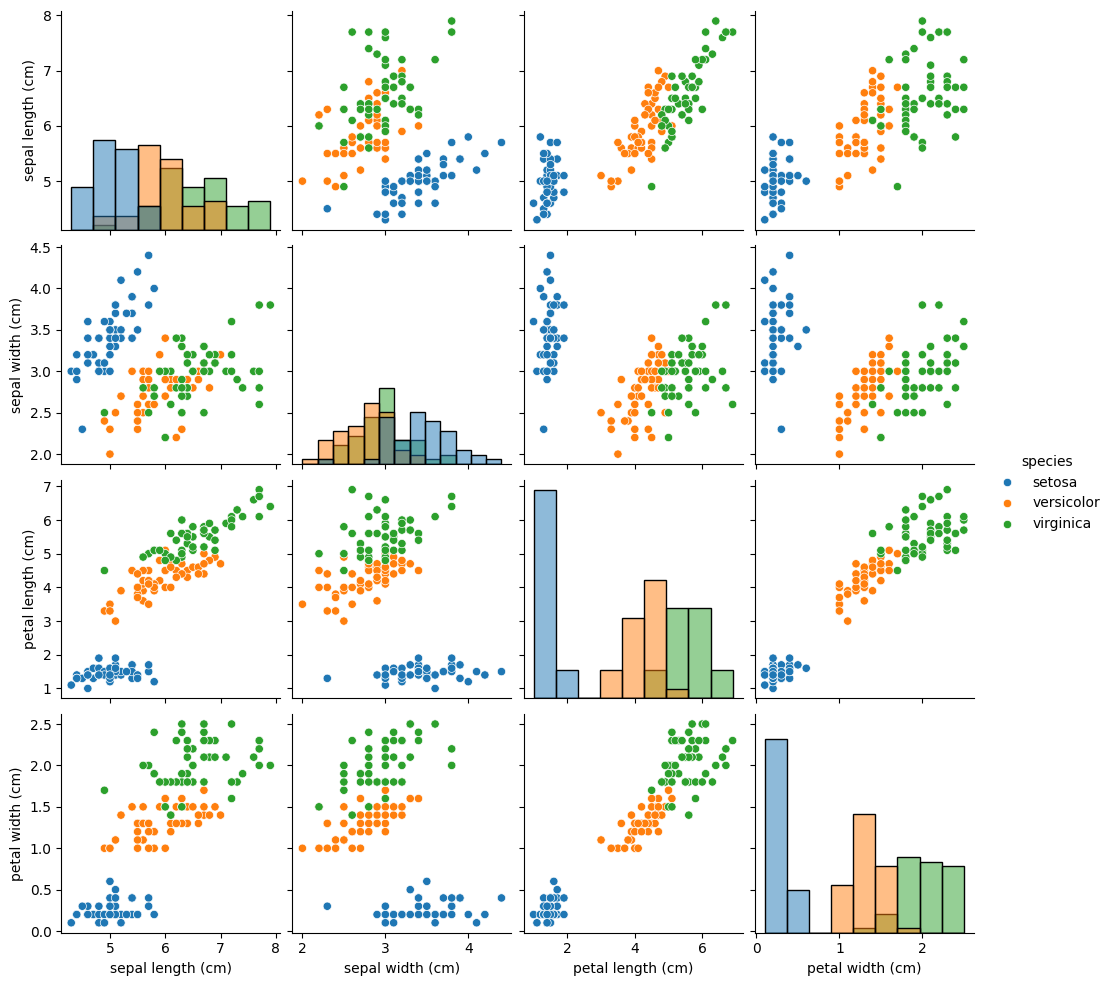

In [5]:
df_vis = X.copy()
df_vis['species'] = [iris.target_names[i] for i in y]

sns.pairplot(df_vis, hue='species', diag_kind='hist')
plt.show()

Como se puede ver, la clase *setosa* es claramente separable de las otras dos, mientras que *versicolor* y *virginica* presentan algo de solapamiento.

## 3. División en entrenamiento y prueba

Dividimos los datos en un 70% para entrenamiento y 30% para prueba.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (105, 4)
Tamaño de prueba: (45, 4)


## 4. Estandarización de las variables

Algunos modelos como SVM son sensibles a la escala de las variables, por lo que es buena práctica estandarizarlas (media 0 y desviación estándar 1).

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 5. Modelo 1: Support Vector Machine (SVM)

El **SVM** busca el hiperplano que mejor separa las clases maximizando el margen entre ellas. Para problemas no lineales, usamos un *kernel* (por defecto el `rbf`).

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mdl_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
mdl_svm.fit(X_train_sc, y_train)
y_pred_svm = mdl_svm.predict(X_test_sc)
print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

Accuracy SVM: 0.9333333333333333

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



### Preguntas
* ¿Qué pasa si cambias el parámetro `C` a un valor muy pequeño (por ejemplo 0.01)? ¿Y si lo aumentas a 100?
* Prueba con el kernel `linear` y compara resultados.

## 6. Modelo 2: Random Forest

El **Random Forest** es un ensamble de árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos y de las variables, y la predicción final se obtiene por votación mayoritaria.

In [9]:
from sklearn.ensemble import RandomForestClassifier

mdl_rf = RandomForestClassifier(n_estimators=100, random_state=42)
mdl_rf.fit(X_train, y_train)

y_pred_rf = mdl_rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy Random Forest: 0.8888888888888888

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  4 11]]


Accuracy DT: 0.9333333333333333

Matriz de confusión:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


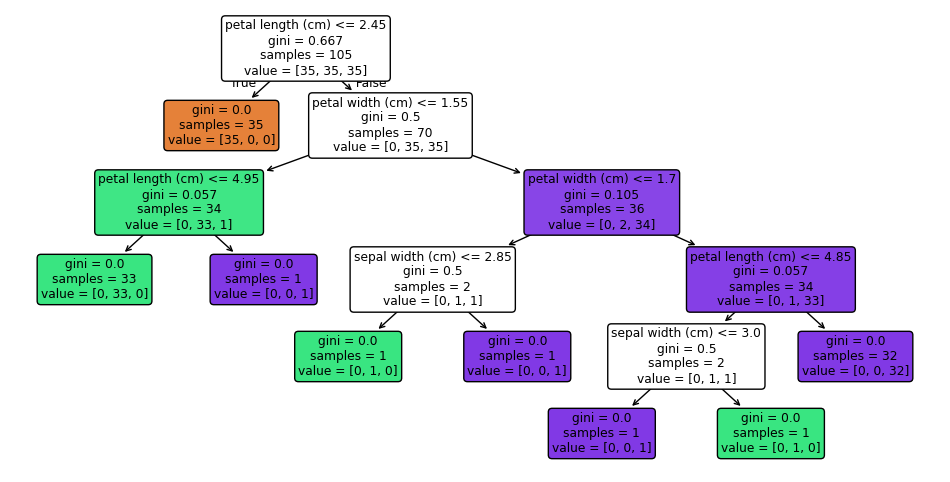

In [10]:

#Implementación del Decision Tree Regressor y visualización
mdl_dt = DecisionTreeClassifier(random_state=42)
mdl_dt.fit(X_train, y_train)

y_pred_dt = mdl_dt.predict(X_test)

print("Accuracy DT:", accuracy_score(y_test, y_pred_dt))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_dt))
plt.figure(figsize=(12, 6))
plot_tree(mdl_dt, filled=True, feature_names=X.columns, rounded=True)
plt.show()

### Importancia de las variables
Una ventaja del Random Forest es que nos dice qué variables son más importantes para la clasificación.

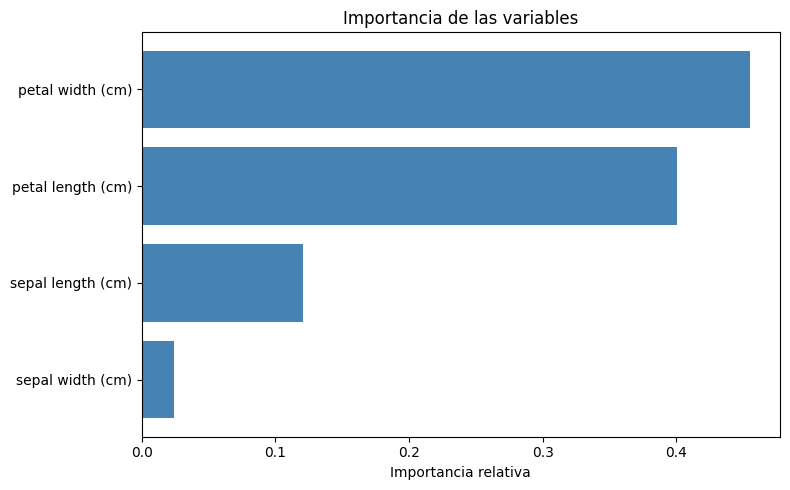

In [11]:
def plot_feature_importances(model, feature_names):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    plt.figure(figsize=(8,5))
    plt.title('Importancia de las variables')
    plt.barh(range(len(indices)), importances[indices], color='steelblue', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importancia relativa')
    plt.tight_layout()
    plt.show()

plot_feature_importances(mdl_rf, iris.feature_names)

## 7. Modelo 3: Gradient Boosting

El **Gradient Boosting** también es un ensamble de árboles, pero a diferencia del Random Forest, los árboles se construyen de forma secuencial: cada nuevo árbol intenta corregir los errores del anterior.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

mdl_gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
mdl_gbm.fit(X_train, y_train)

y_pred_gbm = mdl_gbm.predict(X_test)

print("Accuracy Gradient Boosting:", accuracy_score(y_test, y_pred_gbm))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_gbm))

Accuracy Gradient Boosting: 0.9333333333333333

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


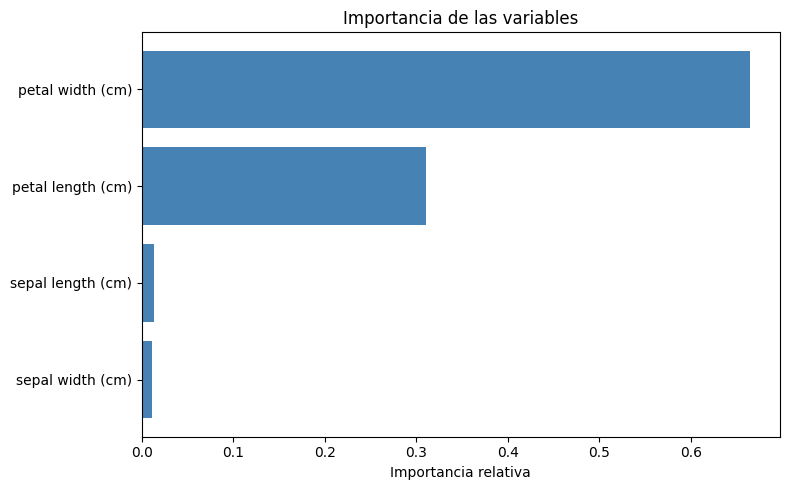

In [13]:
# Importancia de variables del Gradient Boosting
plot_feature_importances(mdl_gbm, iris.feature_names)

## 8. Modelo 4: XGBoost

**XGBoost** (Extreme Gradient Boosting) es una implementación optimizada del Gradient Boosting que suele ofrecer mejor desempeño y mayor velocidad. Es uno de los modelos más populares en competencias de Machine Learning.

In [14]:
# Si no tienes xgboost instalado: !pip install xgboost
mdl_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
mdl_xgb.fit(X_train, y_train)

y_pred_xgb = mdl_xgb.predict(X_test)

print("Accuracy XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy XGBoost: 0.9333333333333333

Matriz de confusión:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


c:\Users\javier\Documents\doc_cuida_paliativos\MetodosAvanzadosInvestigacionCuantitativa\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [11:57:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


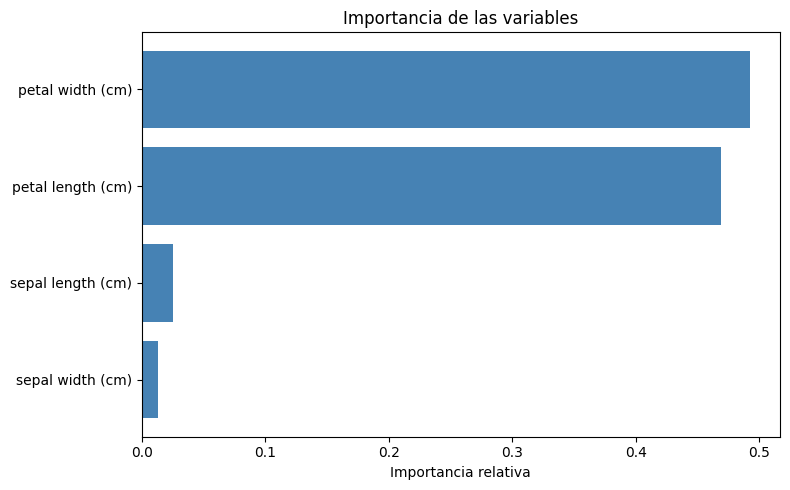

In [15]:
plot_feature_importances(mdl_xgb, iris.feature_names)

## 9. Comparación de modelos

Vamos a juntar los resultados de los 4 modelos en una tabla para compararlos fácilmente.

In [16]:
resultados = pd.DataFrame({
    'Modelo': ['SVM', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gbm),
        accuracy_score(y_test, y_pred_xgb),
    ]
})
resultados.sort_values('Accuracy', ascending=False)

,Modelo,Accuracy
0,SVM,0.933333
2,Gradient Boosting,0.933333
3,XGBoost,0.933333
1,Random Forest,0.888889


## 10. Automatización con PyCaret

**PyCaret** es una librería de bajo código (low-code) que permite entrenar y comparar muchos modelos con muy pocas líneas. Aquí solo veremos las funciones básicas:

- `setup`: configura el experimento.
- `compare_models`: entrena y compara varios modelos automáticamente.
- `pull`: obtiene la tabla de métricas.

> **Nota:** Si no tienes PyCaret instalado, ejecuta `!pip install pycaret` en una celda.

In [17]:
# Importamos PyCaret para clasificación
from pycaret.classification import setup, compare_models,pull,plot_model

# Preparamos un dataframe único con la variable objetivo
df_pycaret = X.copy()
df_pycaret['species'] = y

ModuleNotFoundError: No module named 'pycaret'

In [ ]:
# Configuración del experimento
# 'target' indica la variable a predecir
exp = setup(data=df_pycaret, target='species', session_id=42, verbose=False)

In [ ]:
# Comparamos varios modelos automáticamente ordenados con Recall y tomar solo el primero
best_model = compare_models(sort = 'Recall',n_select=1)
best_model

In [ ]:
df_metricas = pull()
df_metricas.head()

In [ ]:
best_model

In [ ]:
plot_model(best_model, plot = 'confusion_matrix')

In [ ]:
plot_model(best_model, plot = 'auc')

### Conclusiones

* Vimos cómo entrenar 4 modelos clásicos de clasificación: **SVM, Random Forest, Gradient Boosting y XGBoost**.
* En el dataset Iris, todos los modelos alcanzan accuracies muy altos porque el problema es relativamente simple.
* **PyCaret** nos permite hacer todo este proceso de manera automatizada con muy pocas líneas de código, lo cual es muy útil para experimentación rápida.

### Ejercicio
1. Cambia los hiperparámetros de cada modelo y observa cómo cambia el accuracy.
2. Prueba PyCaret con el argumento `fold=10` en `setup` y compara resultados.